# Part 5 Task   

**RQ: Are there distinct patterns in interest about kdramas?** 

Plan:   
1. Get a **list** of title names of each kdrama
2. Access daily pageviews for each kdrama and store into csv for each 
3. Graph 1: calculate total pageviews (sum across "count" column)
4. Graph 2: identify the maximum in "count" and in an additional column of "centered-date", label it as 0 and negative integers before/positive integers after. 

**Table of Contents**  
1. [Exploring the kdramas_2023.csv](#sec1)
2. [Getting data from Wiki](#sec2)
3. [Recreating Graph 1](#sec3)
4. [Recreating Graph 2](#sec4)

<a id="sec1"></a>
## 1. Exploring the kdramas_2023.csv

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('kdramas_2023.csv')
df.shape

(213, 18)

In [4]:
df.columns

Index(['Unnamed: 0', 'Year', 'Title_English', 'Episodes', 'Popularity',
       'Aired', 'Aired On', 'Duration', 'Genres', 'Tags', 'Summary',
       'Title_Korean', 'Also Known As', 'Content Rating', 'Score_Votes',
       'Score', 'Ranked', 'Watchers'],
      dtype='object')

In [5]:
df.head()

,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
0,0,2023,High Cookie (2023),20,1638,"Oct 23, 2023 - Nov 23, 2023",NaN,34 min.,"['Thriller', 'Mystery', 'Youth', 'Fantasy']","['Bully Supporting Character', 'Student Suppor...",A teen fantasy thriller drama that tells the s...,하이쿠키,"Hai Kuki , Haikuki , Hi Cookie , Привет, печен...",18+ Restricted (violence & profanity),2440,7.3,8082,15709
1,1,2023,Strangers Again (2023),12,1515,"Jan 18, 2023 - Feb 23, 2023","Wednesday, Thursday",1 hr. 10 min.,"['Law', 'Romance', 'Drama']","[""Bickering Mains' Relationship"", 'Ex-spouse R...","Divorce lawyer Oh Ha Ra, known as the “goddess...",남이 될 수 있을까?,"Can I Be Someone Else , Can I Be Someone Else?...",15+ - Teens 15 or older,5187,7.2,9766,17025
2,2,2023,Hello! This Is Starbucks (2023),19,99999,"Jun 20, 2023 - Jul 27, 2023","Tuesday, Wednesday, Thursday",1 min.,['Life'],"['Café Setting', 'Short Length Series', 'Web S...",This web drama deals with a theme based on the...,안녕하세요! 스타벅스입니다,Annyeonghaseyo! Seutabeokseuibnida,Not Yet Rated,5,5.9,99999,105
3,3,2023,Adult Kids (2023),8,9473,"Jun 19, 2023 - Aug 7, 2023",Monday,10 min.,"['Life', 'Drama']","['Female Centered Plot', 'Short Length Series'...",A hyper-realistic drama depicting the daily li...,어른애들,"Crianças Adultas , Eoreunaedeul , The Adult Li...",Not Yet Rated,181,7.1,10086,1250
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [9]:
df[df['Title_English']=='My Demon (2023)']

,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [ ]:
kdramas_split = df['Title_English'].apply(lambda x: x.split(' ('))
kdramas_series = kdramas_split.apply(lambda x: x[0])
kdramas_list = kdramas_series.tolist()
kdramas_list[:5]


['High Cookie',
 'Strangers Again',
 'Hello! This Is Starbucks',
 'Adult Kids',
 'My Demon']

In [161]:
len(kdramas_list)

213

## 2. Wiki

In [76]:
from mwclient import Site
site = Site('en.wikipedia.org')
page = site.pages[kdramas_list[0]]
page

<Page object 'High Cookie' for <Site object 'en.wikipedia.org/w/'>>

In [125]:
from mwviews.api import PageviewsClient

p = PageviewsClient(user_agent="Kdrama Lover (wendy_wellesley@gmail.com)")

data = p.article_views('en.wikipedia', 'High Cookie',  start='20260601', end='20260608') 
type(data)

collections.defaultdict

In [127]:
data = dict(data)

In [133]:
data.keys()

dict_keys([datetime.datetime(2026, 6, 1, 0, 0), datetime.datetime(2026, 6, 2, 0, 0), datetime.datetime(2026, 6, 3, 0, 0), datetime.datetime(2026, 6, 4, 0, 0), datetime.datetime(2026, 6, 5, 0, 0), datetime.datetime(2026, 6, 6, 0, 0), datetime.datetime(2026, 6, 7, 0, 0), datetime.datetime(2026, 6, 8, 0, 0)])

THe keys are all of the dates, which we want as the indices for corresponding pageviews.

Now we want to try to only extract the values of values ("None" or a number), which will be our pageviews data.

In [129]:
for v in data.values():
    print(v.values())

dict_values([101])
dict_values([146])
dict_values([126])
dict_values([112])
dict_values([241])
dict_values([552])
dict_values([586])
dict_values([571])


In [142]:
new_dict = {}
for date, inner_dict in data.items(): # we are constructing a dictionary so that the date corresponds to the views directly
    for key, value in inner_dict.items():
        if key not in new_dict:
            new_dict[key] = {}
        new_dict[key][date] = value

In [143]:
new_dict

{'High_Cookie': {datetime.datetime(2026, 6, 1, 0, 0): 101,
  datetime.datetime(2026, 6, 2, 0, 0): 146,
  datetime.datetime(2026, 6, 3, 0, 0): 126,
  datetime.datetime(2026, 6, 4, 0, 0): 112,
  datetime.datetime(2026, 6, 5, 0, 0): 241,
  datetime.datetime(2026, 6, 6, 0, 0): 552,
  datetime.datetime(2026, 6, 7, 0, 0): 586,
  datetime.datetime(2026, 6, 8, 0, 0): 571}}

PUTTING IT ALL TOGEHTER:

In [ ]:
from mwviews.api import PageviewsClient
from requests import HTTPError

p = PageviewsClient(user_agent="Student researcher interested in kdramas (wellesley_wendy@gmail.com)")

total = {}
exception_list = []

# just testing
for k in kdramas_list:
    page = site.pages[k]
    revisions = [rev for rev in page.revisions()] 
    if len(revisions) > 0: # this is to make sure that the page actually has a history 

        try:
            data = p.article_views('en.wikipedia', k, 
                       start='20220601', end='20240601')
            
            new_dict = {}
            for date, inner_dict in data.items(): # we are constructing a dictionary so that the date corresponds to the views directly
                for key, value in inner_dict.items():
                    if key not in new_dict:
                        new_dict[key] = {}
                    new_dict[key][date] = value
            # kdrama_views = dict(data.items()) # so the key of date can correspond to value of views directly
            total.update(new_dict)
        except Exception:
            print(f"ERROR while fetching and parsing {k}")
            exception_list.append(k)
        except HTTPError:
            print("Too many requests")
            result = kdramas_list[kdramas_list.index(k):]
            remaining_list = kdramas_list[result:]
    else:
        pass

HTTPError: 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?prop=revisions&titles=Soundtrack&rvdir=older&rvprop=ids%7Ctimestamp%7Cflags%7Ccomment%7Cuser&rvlimit=50&rvcontinue=20060730115423%7C66673647&continue=%7C%7Cuserinfo&meta=userinfo&uiprop=blockinfo%7Chasmsg&action=query&format=json

In [331]:
len(total)

17

732 is the number of days between the start and end date!

In [162]:
total['Strangers_Again']

{datetime.datetime(2022, 6, 1, 0, 0): 4,
 datetime.datetime(2022, 6, 2, 0, 0): 1,
 datetime.datetime(2022, 6, 3, 0, 0): 7,
 datetime.datetime(2022, 6, 4, 0, 0): 3,
 datetime.datetime(2022, 6, 5, 0, 0): 2,
 datetime.datetime(2022, 6, 6, 0, 0): 3,
 datetime.datetime(2022, 6, 7, 0, 0): 4,
 datetime.datetime(2022, 6, 8, 0, 0): 4,
 datetime.datetime(2022, 6, 9, 0, 0): 2,
 datetime.datetime(2022, 6, 10, 0, 0): 8,
 datetime.datetime(2022, 6, 11, 0, 0): 8,
 datetime.datetime(2022, 6, 12, 0, 0): 6,
 datetime.datetime(2022, 6, 13, 0, 0): 1,
 datetime.datetime(2022, 6, 14, 0, 0): 8,
 datetime.datetime(2022, 6, 15, 0, 0): 5,
 datetime.datetime(2022, 6, 16, 0, 0): 6,
 datetime.datetime(2022, 6, 17, 0, 0): 4,
 datetime.datetime(2022, 6, 18, 0, 0): 6,
 datetime.datetime(2022, 6, 19, 0, 0): None,
 datetime.datetime(2022, 6, 20, 0, 0): 6,
 datetime.datetime(2022, 6, 21, 0, 0): 3,
 datetime.datetime(2022, 6, 22, 0, 0): 8,
 datetime.datetime(2022, 6, 23, 0, 0): 4,
 datetime.datetime(2022, 6, 24, 0, 0): 5

However, we can see that there were NO views around this arbitrary start date that we set. Therefore, our data collection must be able to retrieve the date of the very first revision or creation of the page. IF it did not exist before 2022 06 01, then we use that date instead.

In [60]:
revisions = [rev for rev in page.revisions()]
len(revisions)

54

The last entry of revisions would be the creation date of the page!

In [62]:
revisions[-1]

OrderedDict([('revid', 1185825891),
             ('parentid', 0),
             ('user', 'Sunshine Owl'),
             ('timestamp',
              time.struct_time(tm_year=2023, tm_mon=11, tm_mday=19, tm_hour=6, tm_min=39, tm_sec=44, tm_wday=6, tm_yday=323, tm_isdst=-1)),
             ('comment',
              "[[WP:AES|←]]Created page with '==HIGH COOKIE== {{Short description|2023 South Korean television series}} {{Infobox television | image                =  [[File:High Cookie (2023).jpg|frameless|High Cookie (2023)]] | image_upright        = 1.15 | caption              = Promotional poster | alt_name             = ''High Cookie'' | native_name          = {{Infobox Korean television name|hangul=하이쿠키 |rr= High Cookie |}} | genre                = {{plainlist| * [[Mystery]] * [[Thriller]...'")])

Now, let's turn the timestamp in the time.struct_time form into a datetime object so we can parse it easily!

In [193]:
from time import mktime
from datetime import datetime

In [194]:
creation_date = datetime.fromtimestamp(mktime(revisions[-1]['timestamp']))
creation_date

datetime.datetime(2002, 3, 29, 16, 4, 14)

<a id="sec3"></a>
## 3. Recreating Graph 1

In [332]:
df = pd.DataFrame(total)
df

,High_Cookie,Strangers_Again,My_Demon,Longing_for_You,Intern,Why_R_U?,Doona!,Love_to_Hate_You,Race,Boyhood,Divorce_Attorney_Shin,The_Story_of_Park's_Marriage_Contract,Love_Tractor,Twinkling_Watermelon,Live_Your_Own_Life,A_Time_Called_You,A_Breeze_of_Love
2022-06-01,NaN,4.0,NaN,2.0,58,115,NaN,40,150,28,NaN,NaN,31,NaN,NaN,134,NaN
2022-06-02,NaN,1.0,NaN,2.0,47,100,NaN,60,197,15,NaN,NaN,22,NaN,NaN,128,NaN
2022-06-03,NaN,7.0,NaN,2.0,52,79,NaN,32,153,28,NaN,NaN,27,NaN,NaN,127,NaN
2022-06-04,NaN,3.0,NaN,4.0,41,86,NaN,27,156,18,NaN,NaN,22,NaN,NaN,154,NaN
2022-06-05,NaN,2.0,NaN,3.0,40,75,NaN,39,159,23,NaN,NaN,22,NaN,NaN,137,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-28,123.0,5.0,1620.0,2.0,51,25,614.0,60,188,15,146.0,488.0,18,2032.0,177.0,957,NaN
2024-05-29,110.0,6.0,1566.0,2.0,43,40,517.0,108,230,22,146.0,548.0,21,2205.0,198.0,1001,NaN
2024-05-30,117.0,3.0,1480.0,3.0,54,24,522.0,59,215,12,137.0,555.0,17,2169.0,185.0,956,NaN
2024-05-31,129.0,1.0,1572.0,2.0,62,36,514.0,80,179,11,161.0,584.0,19,2114.0,184.0,903,NaN


Making several logistical adjustments:

In [333]:
df = df.fillna(0)
df = df.convert_dtypes()

Calculating the aggregate of a column:

In [334]:
df.High_Cookie.sum()

np.int64(104622)

In [335]:
pageviews_sums = df.sum().sort_values(ascending=True)
pageviews_sums

A_Breeze_of_Love                             102
Longing_for_You                             1179
Strangers_Again                             5659
Boyhood                                    14696
Love_Tractor                               23092
Intern                                     35617
Why_R_U?                                   40618
Love_to_Hate_You                           69066
High_Cookie                               104622
Race                                      126594
Live_Your_Own_Life                        279783
Divorce_Attorney_Shin                     303293
The_Story_of_Park's_Marriage_Contract     918455
Doona!                                   1033094
A_Time_Called_You                        1349860
Twinkling_Watermelon                     2061432
My_Demon                                 2822146
dtype: Int64

In [336]:
import matplotlib.pyplot as plt

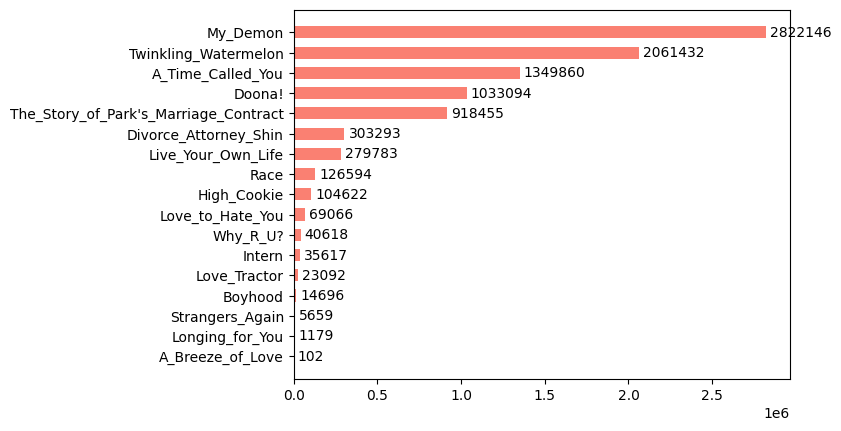

In [337]:
fig, ax = plt.subplots()
chart = ax.barh(pageviews_sums.index, pageviews_sums.values, color='salmon', height=0.6)

ax.bar_label(chart, fmt='%.0f', padding=3)
plt.show()

<a id="sec4"></a>
## 4. Recreating Graph 2

The idea is to find the row with the maximum number of views and the corresponding date, then creating a new column with a centered date.

In [236]:
df[df.High_Cookie==df.High_Cookie.max()]

,High_Cookie,Strangers_Again,My_Demon,Longing_for_You,Intern,Why_R_U?,Doona!,Love_to_Hate_You,Race,Boyhood,...,A_Breeze_of_Love,Fling,Delivery_Man,King_the_Land,Our_Blooming_Youth,Agency,Evilive,Numbers,Woman_in_a_Veil,Tale_of_the_Nine-Tailed_1938
2023-11-24,2277,6,24202,1,29,37,4216,68,254,11,...,0,6,2,2759,624,81,66,30,113,7


This is not really going to work because we only want one of the dramas if it's based on the maximum value for ONE drama. So we will revert back to series.

In [265]:
series_dict = {key: pd.Series(val) for key, val in total.items()}
len(series_dict)

26

In [238]:
series_dict['High_Cookie'].max()

np.float64(2277.0)

In [248]:
temp_df = pd.DataFrame(series_dict['High_Cookie'], columns =['views']).fillna(0)
temp_df

,views
2022-06-01,0.0
2022-06-02,0.0
2022-06-03,0.0
2022-06-04,0.0
2022-06-05,0.0
...,...
2024-05-28,123.0
2024-05-29,110.0
2024-05-30,117.0
2024-05-31,129.0


In [249]:
temp_df[temp_df['views'] == temp_df['views'].max()]

,views
2023-11-24,2277.0


In [258]:
maximum_date = temp_df[temp_df['views'] == temp_df['views'].max()].index
temp_df['date'] = temp_df.index

Now we will make a new column!

In [259]:
temp_df['centered_date'] = temp_df.date.apply(lambda x: (x-maximum_date).days.item())

In [260]:
temp_df

,views,date,centered_date
2022-06-01,0.0,2022-06-01,-541
2022-06-02,0.0,2022-06-02,-540
2022-06-03,0.0,2022-06-03,-539
2022-06-04,0.0,2022-06-04,-538
2022-06-05,0.0,2022-06-05,-537
...,...,...,...
2024-05-28,123.0,2024-05-28,186
2024-05-29,110.0,2024-05-29,187
2024-05-30,117.0,2024-05-30,188
2024-05-31,129.0,2024-05-31,189


Let's try to generate an example of the graph:

(-200.0, 200.0)

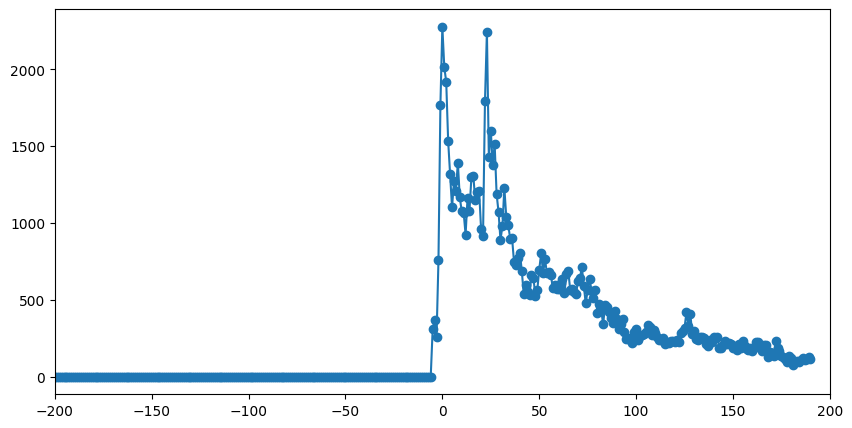

In [270]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temp_df['centered_date'], temp_df['views'], marker='o', linestyle='-')
ax.set_xlim(-200, 200)

Now putting all of this together:

In [ ]:
total_dict = {}
for name, values in total.items():
    df = pd.DataFrame(series_dict[name], columns =['views']).fillna(0)
    maximum_date = df[df['views'] == df['views'].max()].index
    df['date'] = df.index
    df['centered_date'] = df.date.apply(lambda x: (x-maximum_date).days.item())
    total_dict[name] = df

In [316]:
for index, data in enumerate(total_dict):
    print(data)

High_Cookie
Strangers_Again
My_Demon
Longing_for_You
Intern
Why_R_U?
Doona!
Love_to_Hate_You
Race
Boyhood
Divorce_Attorney_Shin
The_Story_of_Park's_Marriage_Contract
Love_Tractor
Twinkling_Watermelon
Live_Your_Own_Life
A_Time_Called_You
A_Breeze_of_Love
Fling
Delivery_Man
King_the_Land
Our_Blooming_Youth
Agency
Evilive
Numbers
Woman_in_a_Veil
Tale_of_the_Nine-Tailed_1938


Let's only print 10:

IndexError: index 10 is out of bounds for axis 0 with size 10

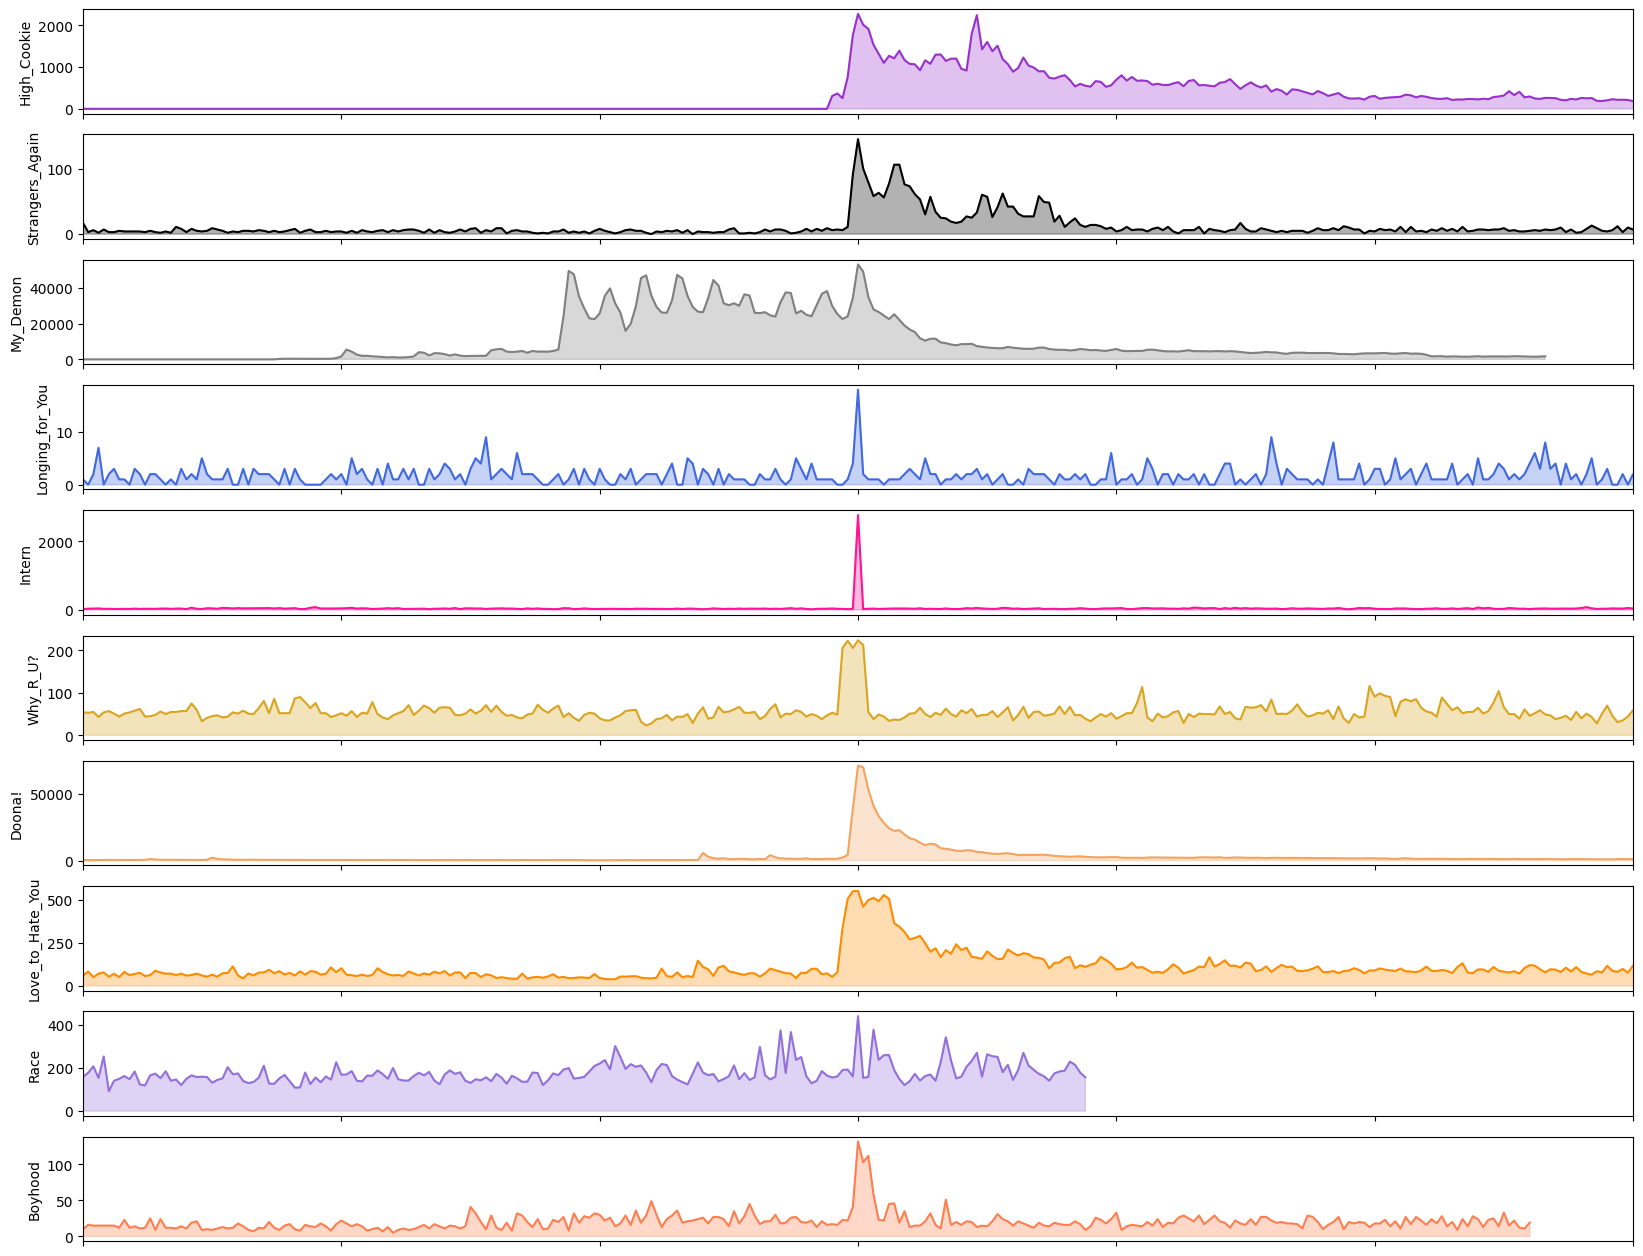

In [338]:
# the plot related color choices are from GenAI
import random
import matplotlib.colors as mcolors
color_names = list(mcolors.CSS4_COLORS.keys())

fig, axes = plt.subplots(10,1, figsize=(20, 16))

for index, data in enumerate(total_dict):
    ax = axes[index]

    random_color = random.choice(color_names)
    ax.plot(total_dict[data]["centered_date"], total_dict[data]["views"], color=random_color)
    ax.fill_between(total_dict[data]["centered_date"], total_dict[data]["views"], color=random_color, alpha=0.3)
    ax.set_xticklabels([])
    ax.set_xlim(-150, 150)
    ax.set_ylabel(data)
